
# Fast Beam-Native CRT Generator (Conv1D)
## Faster CIFAR-10 / MNIST prototype using a Conv1D beam decoder

This notebook keeps the same core idea:

- the model does **not** output pixels directly
- it outputs a **beam program over time**
- a differentiable **CRT simulator** draws the final image

But it replaces the expensive Transformer decoder with a **Conv1D temporal decoder**, which is much faster and scales better to long raster sequences.

## Why this version exists
The Transformer version is expensive because the beam sequence is long.  
This version uses temporal convolutions over the beam sequence:

- faster
- simpler
- better for quick experiments
- still beam-native

## Best use
1. Start with `DATASET_NAME = "MNIST"` to verify sharp beam drawing
2. Then switch to `CIFAR10`


## 1. Setup

In [ ]:

# Uncomment if needed
# !pip install -q torch torchvision matplotlib tqdm


In [ ]:

import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 2. Config

In [ ]:

@dataclass
class Config:
    dataset_name: str = "CIFAR10"   # "MNIST" or "CIFAR10"

    image_size: int = 32
    channels: int = 3
    num_classes: int = 10

    train_subset: int = 8000
    test_subset: int = 2000

    batch_size: int = 32
    num_workers: int = 0

    samples_per_pixel: int = 1
    flyback_frac: float = 0.10

    beam_sigma_min: float = 0.18
    beam_sigma_max: float = 0.55
    persistence: float = 0.65
    retrace_decay: float = 0.05
    beam_gain: float = 1.20

    latent_dim: int = 96
    class_embed_dim: int = 32
    time_feat_dim: int = 64
    base_width: int = 192
    num_blocks: int = 8
    dilation_cycle: tuple = (1, 2, 4, 8)

    lr: float = 2e-4
    epochs: int = 8
    kl_weight: float = 2e-4
    beam_loss_weight: float = 0.25
    edge_loss_weight: float = 0.20
    smooth_reg_weight: float = 1e-4
    focus_reg_weight: float = 5e-4
    energy_reg_weight: float = 2e-5

    seed: int = 42

cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)

if cfg.dataset_name.upper() == "MNIST":
    cfg.channels = 1
else:
    cfg.channels = 3

cfg


Config(dataset_name='CIFAR10', image_size=32, channels=3, num_classes=10, train_subset=8000, test_subset=2000, batch_size=32, num_workers=0, samples_per_pixel=1, flyback_frac=0.1, beam_sigma_min=0.18, beam_sigma_max=0.55, persistence=0.65, retrace_decay=0.05, beam_gain=1.2, latent_dim=96, class_embed_dim=32, time_feat_dim=64, base_width=192, num_blocks=8, dilation_cycle=(1, 2, 4, 8), lr=0.0002, epochs=8, kl_weight=0.0002, beam_loss_weight=0.25, edge_loss_weight=0.2, smooth_reg_weight=0.0001, focus_reg_weight=0.0005, energy_reg_weight=2e-05, seed=42)

## 3. CRT raster path

In [ ]:

def generate_crt_raster_path(w, h, samples_per_pixel=1, flyback_frac=0.10):
    active_per_row = w * samples_per_pixel
    flyback_steps = max(1, int(active_per_row * flyback_frac))

    xs, ys, beam_on = [], [], []
    for row in range(h):
        y = row + 0.5

        for i in range(active_per_row):
            x = (i / max(active_per_row - 1, 1)) * (w - 1)
            xs.append(x)
            ys.append(y)
            beam_on.append(1.0)

        for i in range(flyback_steps):
            t = (i + 1) / flyback_steps
            x = (1 - t) * (w - 1)
            xs.append(x)
            ys.append(y)
            beam_on.append(0.0)

    path = np.stack([np.array(xs), np.array(ys)], axis=1).astype(np.float32)
    beam_on = np.array(beam_on, dtype=np.float32)
    return path, beam_on

path_np, beam_on_np = generate_crt_raster_path(
    cfg.image_size, cfg.image_size, cfg.samples_per_pixel, cfg.flyback_frac
)
SEQ_LEN = len(path_np)
print("sequence length:", SEQ_LEN)


sequence length: 1120


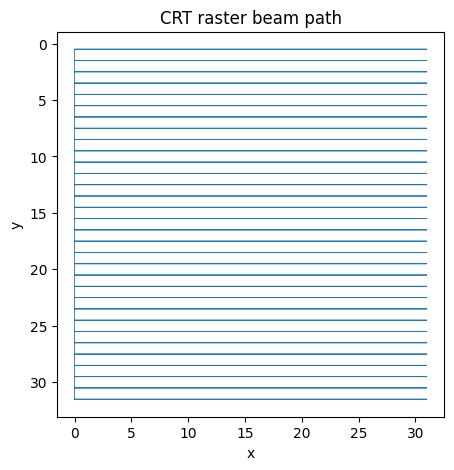

In [ ]:

plt.figure(figsize=(5,5))
plt.plot(path_np[:,0], path_np[:,1], linewidth=0.6)
plt.gca().invert_yaxis()
plt.title("CRT raster beam path")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 4. Sharp differentiable CRT renderer

In [ ]:

class SharpBeamNativeCRTRenderer(nn.Module):
    def __init__(self, path_np, beam_on_np, image_size, sigma_min, sigma_max, persistence, retrace_decay, beam_gain=1.0):
        super().__init__()
        self.image_size = image_size
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.persistence = persistence
        self.retrace_decay = retrace_decay
        self.beam_gain = beam_gain

        self.register_buffer("path_x", torch.from_numpy(path_np[:, 0]).float())
        self.register_buffer("path_y", torch.from_numpy(path_np[:, 1]).float())
        self.register_buffer("beam_on", torch.from_numpy(beam_on_np).float())

        yy, xx = torch.meshgrid(
            torch.arange(image_size).float(),
            torch.arange(image_size).float(),
            indexing="ij"
        )
        self.register_buffer("grid_x", xx[None, None, :, :])
        self.register_buffer("grid_y", yy[None, None, :, :])

    def forward(self, drive, focus_logits):
        B, T, C = drive.shape
        beam_on = self.beam_on.view(1, T, 1)
        drive = drive * beam_on

        sigma = torch.sigmoid(focus_logits)
        sigma = self.sigma_min + (self.sigma_max - self.sigma_min) * sigma

        x = self.path_x.view(1, T, 1, 1)
        y = self.path_y.view(1, T, 1, 1)

        dx2 = (self.grid_x - x) ** 2
        dy2 = (self.grid_y - y) ** 2
        sig2 = sigma.view(B, T, 1, 1) ** 2

        kernel = torch.exp(-(dx2 + dy2) / (2.0 * sig2 + 1e-8))
        kernel = kernel.unsqueeze(1)

        drive = drive.permute(0, 2, 1).unsqueeze(-1).unsqueeze(-1)
        deposited = (drive * kernel).sum(dim=2)

        out = deposited.clone()
        out[:, :, 1:, :] = out[:, :, 1:, :] + self.retrace_decay * out[:, :, :-1, :]

        out = 1.0 - torch.exp(-self.beam_gain * self.persistence * out)
        return out.clamp(0.0, 1.0)

renderer = SharpBeamNativeCRTRenderer(
    path_np=path_np,
    beam_on_np=beam_on_np,
    image_size=cfg.image_size,
    sigma_min=cfg.beam_sigma_min,
    sigma_max=cfg.beam_sigma_max,
    persistence=cfg.persistence,
    retrace_decay=cfg.retrace_decay,
    beam_gain=cfg.beam_gain,
).to(device)


## 5. Dataset

In [ ]:

def make_dataset(cfg):
    if cfg.dataset_name.upper() == "MNIST":
        transform = transforms.Compose([
            transforms.Resize((cfg.image_size, cfg.image_size)),
            transforms.ToTensor(),
        ])
        train_raw = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
        test_raw = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    elif cfg.dataset_name.upper() == "CIFAR10":
        transform = transforms.Compose([
            transforms.Resize((cfg.image_size, cfg.image_size)),
            transforms.ToTensor(),
        ])
        train_raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
        test_raw = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    else:
        raise ValueError("dataset_name must be 'MNIST' or 'CIFAR10'")

    if cfg.train_subset is not None:
        train_raw = Subset(train_raw, list(range(min(cfg.train_subset, len(train_raw)))))
    if cfg.test_subset is not None:
        test_raw = Subset(test_raw, list(range(min(cfg.test_subset, len(test_raw)))))

    return train_raw, test_raw

train_raw, test_raw = make_dataset(cfg)
len(train_raw), len(test_raw)


100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


(8000, 2000)

## 6. Convert image to teacher beam drive

In [ ]:

def image_to_beam_drive(image, path_t, beam_on_t):
    c, h, w = image.shape
    xs = 2.0 * path_t[:, 0] / (w - 1) - 1.0
    ys = 2.0 * path_t[:, 1] / (h - 1) - 1.0
    grid = torch.stack([xs, ys], dim=-1).view(1, -1, 1, 2)

    sampled = F.grid_sample(
        image.unsqueeze(0),
        grid,
        mode="bilinear",
        align_corners=True
    )
    drive = sampled.squeeze(0).squeeze(-1).transpose(0, 1).contiguous()
    drive = drive * beam_on_t[:, None]
    return drive

path_t = torch.from_numpy(path_np)
beam_on_t = torch.from_numpy(beam_on_np)

class BeamProgramDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, path_t, beam_on_t):
        self.base_ds = base_ds
        self.path_t = path_t
        self.beam_on_t = beam_on_t

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img, label = self.base_ds[idx]
        beam_drive = image_to_beam_drive(img, self.path_t, self.beam_on_t)
        return img, label, beam_drive

train_ds = BeamProgramDataset(train_raw, path_t, beam_on_t)
test_ds = BeamProgramDataset(test_raw, path_t, beam_on_t)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)


## 7. Visual sanity check

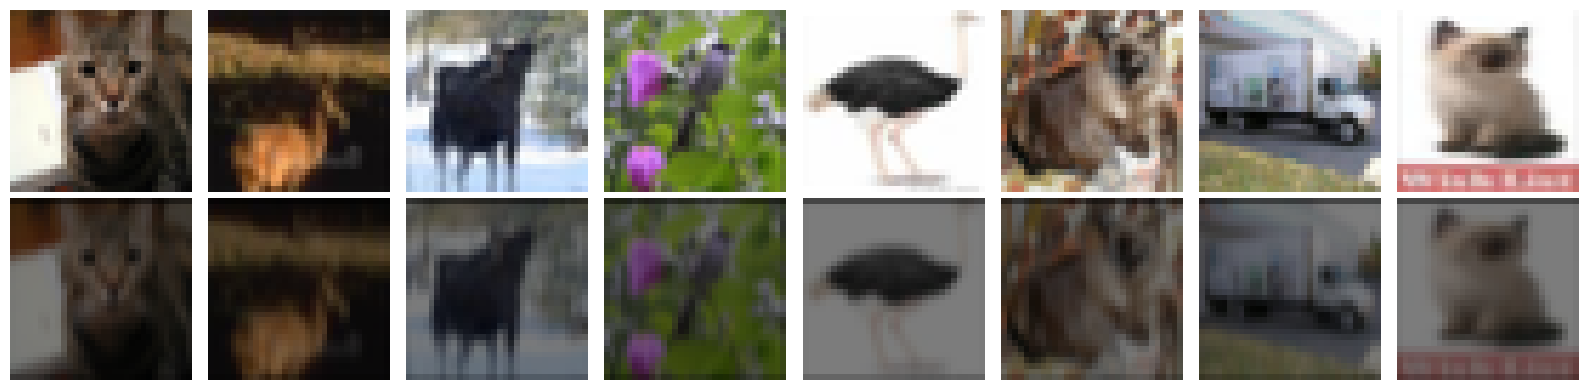

In [ ]:

images, labels, beam_drive = next(iter(train_loader))

with torch.no_grad():
    target_render = renderer(
        beam_drive[:8].to(device),
        torch.zeros(8, SEQ_LEN, 1, device=device)
    ).cpu()

n = min(8, images.shape[0])
fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
for i in range(n):
    if images.shape[1] == 1:
        axes[0, i].imshow(images[i,0], cmap="gray")
        axes[1, i].imshow(target_render[i,0], cmap="gray")
    else:
        axes[0, i].imshow(images[i].permute(1,2,0))
        axes[1, i].imshow(target_render[i].permute(1,2,0))
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("clean")
axes[1, 0].set_ylabel("beam-rendered")
plt.tight_layout()
plt.show()


## 8. Positional/time features

In [ ]:

def sinusoidal_positions(n_positions, dim):
    pe = torch.zeros(n_positions, dim)
    pos = torch.arange(n_positions, dtype=torch.float32).unsqueeze(1)
    div = torch.exp(torch.arange(0, dim, 2, dtype=torch.float32) * -(math.log(10000.0) / dim))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

def path_positional_encoding(path_np, dim, image_size):
    coords = torch.from_numpy(path_np).float()
    x = coords[:, 0:1] / (image_size - 1)
    y = coords[:, 1:2] / (image_size - 1)
    half = dim // 2

    def encode(v, d):
        pe = torch.zeros(v.shape[0], d)
        div = torch.exp(torch.arange(0, d, 2, dtype=torch.float32) * -(math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(v * div)
        pe[:, 1::2] = torch.cos(v * div)
        return pe

    return torch.cat([encode(x, half), encode(y, dim - half)], dim=1)

time_feat = torch.cat([
    sinusoidal_positions(len(path_np), cfg.time_feat_dim),
    path_positional_encoding(path_np, cfg.time_feat_dim, cfg.image_size),
    torch.from_numpy(beam_on_np).float().unsqueeze(1)
], dim=1)
time_feat.shape


torch.Size([1120, 129])

## 9. Encoder + Conv1D beam decoder

In [ ]:

class ConvEncoder(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(256, 256, 4, 2, 1), nn.SiLU(),
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512), nn.SiLU(),
        )
        self.mu = nn.Linear(512, latent_dim)
        self.logvar = nn.Linear(512, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)

class Conv1DResidualBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=padding, dilation=dilation),
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv1d(channels, channels, kernel_size=3, padding=padding, dilation=dilation),
            nn.GroupNorm(8, channels),
        )
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(x + self.net(x))

class Conv1DBeamDecoder(nn.Module):
    def __init__(self, cfg, time_feat):
        super().__init__()
        self.cfg = cfg
        self.class_embed = nn.Embedding(cfg.num_classes, cfg.class_embed_dim)
        self.register_buffer("time_feat", time_feat.float())

        in_dim = cfg.latent_dim + cfg.class_embed_dim + time_feat.shape[1]
        self.in_proj = nn.Conv1d(in_dim, cfg.base_width, kernel_size=1)

        blocks = []
        dilations = list(cfg.dilation_cycle)
        for i in range(cfg.num_blocks):
            blocks.append(Conv1DResidualBlock(cfg.base_width, dilation=dilations[i % len(dilations)]))
        self.blocks = nn.Sequential(*blocks)

        self.drive_head = nn.Sequential(
            nn.Conv1d(cfg.base_width, cfg.base_width, kernel_size=1),
            nn.SiLU(),
            nn.Conv1d(cfg.base_width, cfg.channels, kernel_size=1),
        )
        self.focus_head = nn.Sequential(
            nn.Conv1d(cfg.base_width, cfg.base_width, kernel_size=1),
            nn.SiLU(),
            nn.Conv1d(cfg.base_width, 1, kernel_size=1),
        )

    def forward(self, z, labels):
        B = z.shape[0]
        T = self.time_feat.shape[0]

        z_rep = z.unsqueeze(1).expand(B, T, z.shape[1])
        c_rep = self.class_embed(labels).unsqueeze(1).expand(B, T, self.cfg.class_embed_dim)
        t_rep = self.time_feat.unsqueeze(0).expand(B, T, self.time_feat.shape[1])

        x = torch.cat([z_rep, c_rep, t_rep], dim=-1).transpose(1, 2).contiguous()  # (B,F,T)
        x = self.in_proj(x)
        x = self.blocks(x)

        drive = torch.sigmoid(self.drive_head(x)).transpose(1, 2).contiguous()
        focus = self.focus_head(x).transpose(1, 2).contiguous()
        return drive, focus

class BeamNativeConv1DVAE(nn.Module):
    def __init__(self, cfg, time_feat, renderer):
        super().__init__()
        self.cfg = cfg
        self.encoder = ConvEncoder(cfg.channels, cfg.latent_dim)
        self.decoder = Conv1DBeamDecoder(cfg, time_feat)
        self.renderer = renderer

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, images, labels):
        mu, logvar = self.encoder(images)
        z = self.reparameterize(mu, logvar)
        drive, focus = self.decoder(z, labels)
        rendered = self.renderer(drive, focus)
        return {
            "mu": mu,
            "logvar": logvar,
            "z": z,
            "drive": drive,
            "focus": focus,
            "rendered": rendered,
        }

    @torch.no_grad()
    def generate(self, labels, z=None):
        B = labels.shape[0]
        if z is None:
            z = torch.randn(B, self.cfg.latent_dim, device=labels.device)
        drive, focus = self.decoder(z, labels)
        rendered = self.renderer(drive, focus)
        return drive, focus, rendered

model = BeamNativeConv1DVAE(cfg, time_feat, renderer).to(device)
params_m = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"trainable params: {params_m:.2f}M")


trainable params: 4.23M


## 10. Losses

In [ ]:

def kl_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def smoothness_loss(x):
    return (x[:, 1:] - x[:, :-1]).abs().mean()

def sobel_edges(img):
    if img.shape[1] > 1:
        x = img.mean(dim=1, keepdim=True)
    else:
        x = img

    kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=x.dtype, device=x.device).view(1,1,3,3)
    ky = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=x.dtype, device=x.device).view(1,1,3,3)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    return torch.sqrt(gx**2 + gy**2 + 1e-6)

def loss_fn(outputs, target_img, target_beam, cfg):
    rendered = outputs["rendered"]
    pred_beam = outputs["drive"]
    focus = outputs["focus"]
    mu = outputs["mu"]
    logvar = outputs["logvar"]

    loss_img = F.l1_loss(rendered, target_img)
    loss_beam = F.l1_loss(pred_beam, target_beam)
    loss_edge = F.l1_loss(sobel_edges(rendered), sobel_edges(target_img))
    loss_kl = kl_loss(mu, logvar)
    loss_smooth = smoothness_loss(pred_beam)
    loss_focus = focus.abs().mean()
    loss_energy = pred_beam.mean()

    total = (
        loss_img
        + cfg.beam_loss_weight * loss_beam
        + cfg.edge_loss_weight * loss_edge
        + cfg.kl_weight * loss_kl
        + cfg.smooth_reg_weight * loss_smooth
        + cfg.focus_reg_weight * loss_focus
        + cfg.energy_reg_weight * loss_energy
    )

    metrics = {
        "loss": float(total.detach().cpu()),
        "img_l1": float(loss_img.detach().cpu()),
        "beam_l1": float(loss_beam.detach().cpu()),
        "edge_l1": float(loss_edge.detach().cpu()),
        "kl": float(loss_kl.detach().cpu()),
        "smooth": float(loss_smooth.detach().cpu()),
    }
    return total, metrics


## 11. Training

In [ ]:

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, betas=(0.9, 0.95), weight_decay=1e-4)

def train_one_epoch(model, loader, optimizer, cfg):
    model.train()
    logs = []
    pbar = tqdm(loader, leave=False)
    for images, labels, teacher_beam in pbar:
        images = images.to(device)
        labels = labels.to(device)
        teacher_beam = teacher_beam.to(device)

        outputs = model(images, labels)
        loss, metrics = loss_fn(outputs, images, teacher_beam, cfg)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        logs.append(metrics["loss"])
        pbar.set_description(f"loss={np.mean(logs[-20:]):.4f}")
    return float(np.mean(logs))

@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    logs = []
    for images, labels, teacher_beam in loader:
        images = images.to(device)
        labels = labels.to(device)
        teacher_beam = teacher_beam.to(device)

        outputs = model(images, labels)
        loss, _ = loss_fn(outputs, images, teacher_beam, cfg)
        logs.append(float(loss.cpu()))
    return float(np.mean(logs))


In [ ]:

history = {"train": [], "test": []}
for epoch in range(cfg.epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, cfg)
    test_loss = evaluate(model, test_loader, cfg)
    history["train"].append(train_loss)
    history["test"].append(test_loss)
    print(f"epoch {epoch+1}/{cfg.epochs} | train={train_loss:.4f} | test={test_loss:.4f}")


  0%|          | 0/250 [00:00<?, ?it/s]

epoch 1/8 | train=0.3045 | test=0.2812


  0%|          | 0/250 [00:00<?, ?it/s]

epoch 2/8 | train=0.2657 | test=0.2556


  0%|          | 0/250 [00:00<?, ?it/s]

...

epoch 6/8 | train=0.2206 | test=0.2197


  0%|          | 0/250 [00:00<?, ?it/s]

epoch 7/8 | train=0.2160 | test=0.2142


  0%|          | 0/250 [00:00<?, ?it/s]

epoch 8/8 | train=0.2108 | test=0.2105


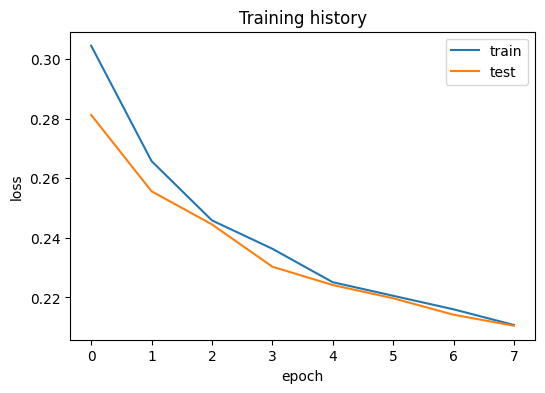

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(history["train"], label="train")
plt.plot(history["test"], label="test")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training history")
plt.legend()
plt.show()


## 12. Reconstruction inspection

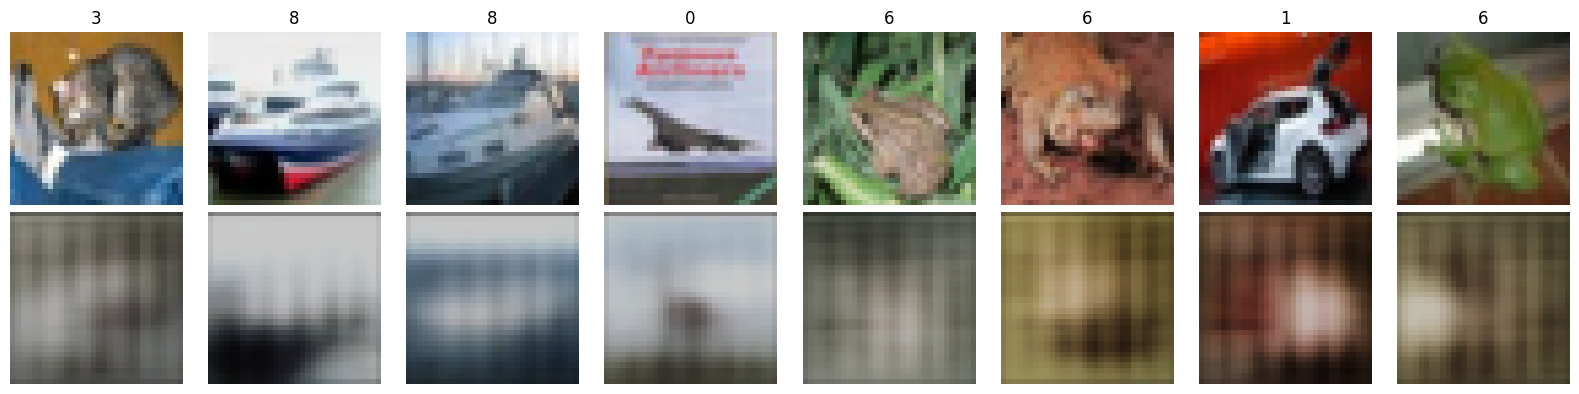

In [ ]:

@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    model.eval()
    images, labels, teacher_beam = next(iter(loader))
    images = images[:n].to(device)
    labels = labels[:n].to(device)

    outputs = model(images, labels)
    rendered = outputs["rendered"].cpu()

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        if images.shape[1] == 1:
            axes[0, i].imshow(images[i,0].cpu(), cmap="gray")
            axes[1, i].imshow(rendered[i,0], cmap="gray")
        else:
            axes[0, i].imshow(images[i].cpu().permute(1,2,0))
            axes[1, i].imshow(rendered[i].permute(1,2,0))
        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[0, i].set_title(str(labels[i].item()))
    axes[0, 0].set_ylabel("target")
    axes[1, 0].set_ylabel("beam")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=8)


## 13. Beam inspection

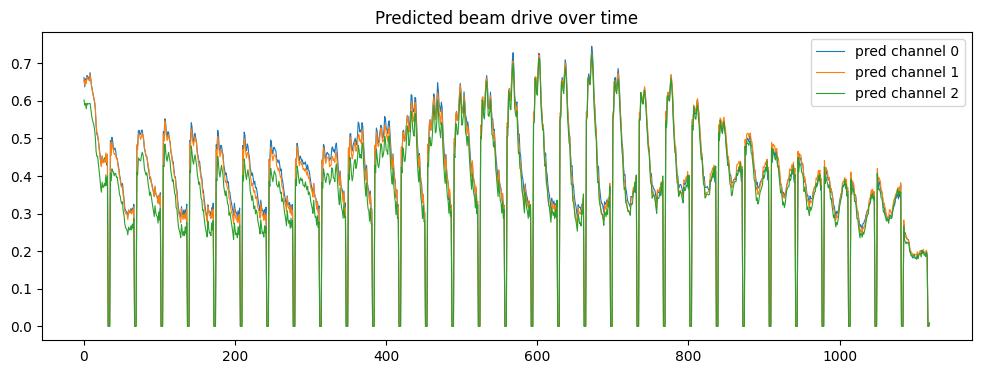

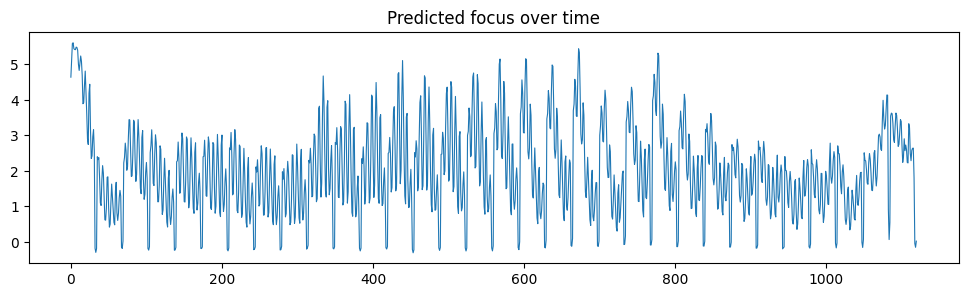

In [ ]:

@torch.no_grad()
def inspect_beam(model, loader, idx=0):
    model.eval()
    images, labels, teacher_beam = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images, labels)
    pred_beam = outputs["drive"].cpu()
    focus = outputs["focus"].cpu()

    plt.figure(figsize=(12,4))
    for c in range(pred_beam.shape[-1]):
        plt.plot(pred_beam[idx,:,c], linewidth=0.8, label=f"pred channel {c}")
    plt.title("Predicted beam drive over time")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(focus[idx,:,0], linewidth=0.8)
    plt.title("Predicted focus over time")
    plt.show()

inspect_beam(model, test_loader, idx=0)


## 14. Generation from random latents

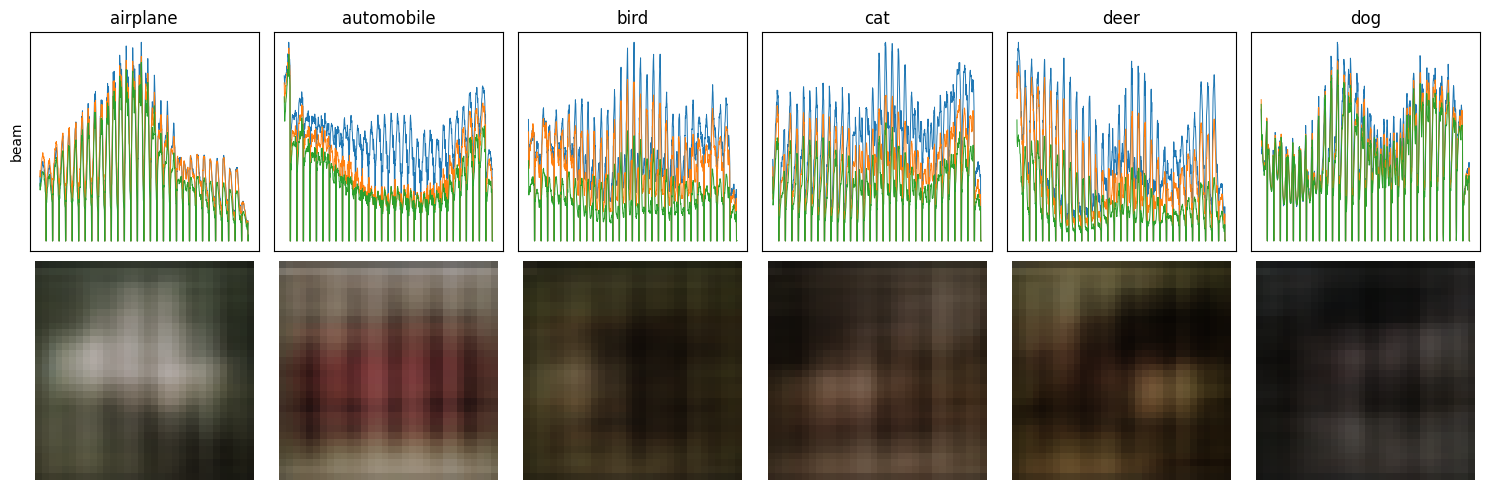

In [ ]:

MNIST_CLASSES = [str(i) for i in range(10)]
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

def class_names(cfg):
    return MNIST_CLASSES if cfg.dataset_name.upper() == "MNIST" else CIFAR10_CLASSES

@torch.no_grad()
def generate_grid(model, cfg, labels_list, seed=0):
    model.eval()
    torch.manual_seed(seed)
    labels = torch.tensor(labels_list, device=device)
    drive, focus, rendered = model.generate(labels)
    names = class_names(cfg)

    fig, axes = plt.subplots(2, len(labels_list), figsize=(2.5*len(labels_list), 5))
    for i, lab in enumerate(labels_list):
        for c in range(drive.shape[-1]):
            axes[0, i].plot(drive[i,:,c].cpu(), linewidth=0.7)
        axes[0, i].set_title(names[lab])
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])

        if rendered.shape[1] == 1:
            axes[1, i].imshow(rendered[i,0].cpu(), cmap="gray")
        else:
            axes[1, i].imshow(rendered[i].cpu().permute(1,2,0))
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("beam")
    axes[1, 0].set_ylabel("image")
    plt.tight_layout()
    plt.show()

generate_grid(model, cfg, [0,1,2,3,4,5], seed=7)


## 15. Time-lapse of beam drawing

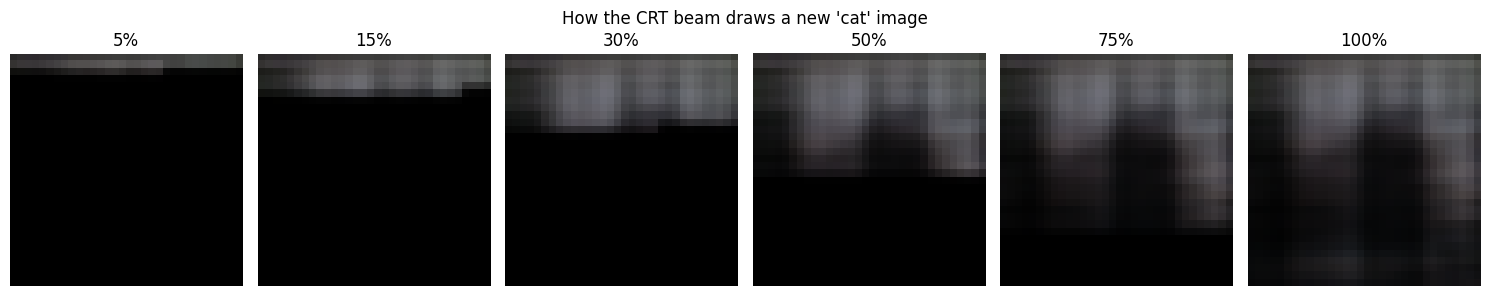

In [ ]:

@torch.no_grad()
def render_partial_sequence(renderer, drive, focus, fractions=(0.05, 0.15, 0.30, 0.50, 0.75, 1.0)):
    imgs = []
    T = drive.shape[1]
    for frac in fractions:
        t_end = max(1, int(T * frac))
        drive_part = drive.clone()
        focus_part = focus.clone()
        drive_part[:, t_end:] = 0.0
        focus_part[:, t_end:] = 0.0
        imgs.append(renderer(drive_part, focus_part))
    return imgs

@torch.no_grad()
def show_timelapse(model, cfg, label=3, seed=0):
    model.eval()
    torch.manual_seed(seed)
    labels = torch.tensor([label], device=device)
    drive, focus, rendered = model.generate(labels)
    partials = render_partial_sequence(renderer, drive, focus)
    name = class_names(cfg)[label]

    fig, axes = plt.subplots(1, len(partials), figsize=(15,3))
    for ax, img, frac in zip(axes, partials, (0.05,0.15,0.30,0.50,0.75,1.0)):
        if img.shape[1] == 1:
            ax.imshow(img[0,0].cpu(), cmap="gray")
        else:
            ax.imshow(img[0].cpu().permute(1,2,0))
        ax.set_title(f"{int(frac*100)}%")
        ax.axis("off")
    plt.suptitle(f"How the CRT beam draws a new '{name}' image")
    plt.tight_layout()
    plt.show()

show_timelapse(model, cfg, label=3, seed=2)


## 16. Save outputs

In [ ]:

out_dir = Path("crt_beam_conv1d_outputs")
out_dir.mkdir(exist_ok=True)

@torch.no_grad()
def save_generation_panel(model, cfg, labels_list, filename="conv1d_beam_panel.png", seed=0):
    model.eval()
    torch.manual_seed(seed)
    labels = torch.tensor(labels_list, device=device)
    drive, focus, rendered = model.generate(labels)
    names = class_names(cfg)

    fig, axes = plt.subplots(2, len(labels_list), figsize=(2.5*len(labels_list), 5))
    for i, lab in enumerate(labels_list):
        for c in range(drive.shape[-1]):
            axes[0, i].plot(drive[i,:,c].cpu(), linewidth=0.7)
        axes[0, i].set_title(names[lab])
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])

        if rendered.shape[1] == 1:
            axes[1, i].imshow(rendered[i,0].cpu(), cmap="gray")
        else:
            axes[1, i].imshow(rendered[i].cpu().permute(1,2,0))
        axes[1, i].axis("off")

    plt.tight_layout()
    save_path = out_dir / filename
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return save_path

save_generation_panel(model, cfg, [0,1,2,3,4,5], filename="conv1d_beam_panel.png", seed=9)


PosixPath('crt_beam_conv1d_outputs/conv1d_beam_panel.png')


## 17. Suggested fast settings

### For fastest proof on CIFAR-10
```python
train_subset = 5000
test_subset = 1000
batch_size = 16
base_width = 128
num_blocks = 6
epochs = 5
```

### For best sanity check
```python
dataset_name = "MNIST"
```

## Next upgrade
If this Conv1D version works and is fast enough, the next strong step is a hierarchical version:
- coarse beam plan
- fine beam modulation
- same CRT renderer
